# PhysioStress — Results Walkthrough

This notebook walks through the final Leave-One-Subject-Out (LOSO) cross-validation results and the interpretability analysis, reading the tables/figures already produced by `src/modeling.py` and `src/interpretability.py`. See `docs/REPORT.md` for the full narrative discussion.

In [ ]:
import sys, os
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import TABLES_DIR, LABEL_NAMES

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 100)

summary = pd.read_csv(os.path.join(TABLES_DIR, "model_comparison.csv"))
summary = summary.sort_values("f1_macro", ascending=False).reset_index(drop=True)
summary


,model,accuracy,f1_macro,loso_acc_std,loso_f1_std
0,Gradient Boosting (HistGB),0.890909,0.862284,6.658791e-02,9.166425e-02
1,Random Forest,0.874747,0.839317,9.641798e-02,1.301094e-01
2,Logistic Regression,0.852525,0.809834,9.709588e-02,1.346290e-01
3,SVM (RBF),0.804040,0.744512,1.103740e-01,1.394858e-01
4,Baseline (Majority Class),0.454545,0.208333,1.723785e-16,5.745950e-17


Best model: Gradient Boosting (HistGB)  (accuracy=0.891, F1-macro=0.862)


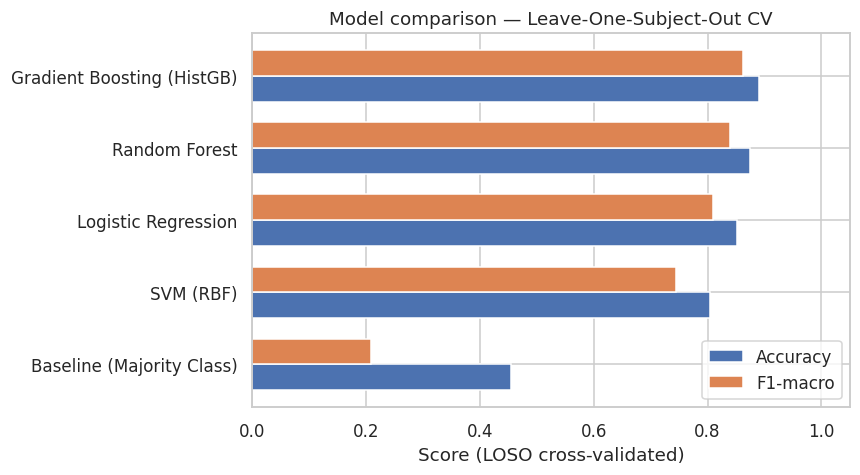

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
d = summary.sort_values("f1_macro")
y = np.arange(len(d))
ax.barh(y - 0.18, d["accuracy"], height=0.36, label="Accuracy", color="#4C72B0")
ax.barh(y + 0.18, d["f1_macro"], height=0.36, label="F1-macro", color="#DD8452")
ax.set_yticks(y); ax.set_yticklabels(d["model"])
ax.set_xlim(0, 1.05); ax.set_xlabel("Score (LOSO cross-validated)")
ax.legend(loc="lower right")
ax.set_title("Model comparison — Leave-One-Subject-Out CV")
plt.tight_layout()
plt.show()

best_model_name = summary.iloc[0]["model"]
print(f"Best model: {best_model_name}  (accuracy={summary.iloc[0]['accuracy']:.3f}, "
      f"F1-macro={summary.iloc[0]['f1_macro']:.3f})")


## Confusion matrix (best model, aggregated across all 15 LOSO folds)

Baseline is classified almost perfectly; nearly all remaining errors are **stress ↔ amusement** confusion — both are high-arousal sympathetic states, so this is the physiologically hardest boundary, not a modeling failure.

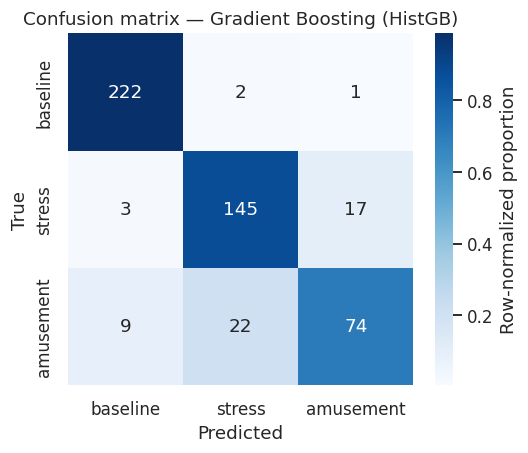

In [ ]:
safe_name = best_model_name.replace(" ", "_").replace("(", "").replace(")", "")
cm = pd.read_csv(os.path.join(TABLES_DIR, f"confusion_matrix_{safe_name}.csv"), index_col=0)
cm_norm = cm.values.astype(float) / cm.values.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4.3))
sns.heatmap(cm_norm, annot=cm.values, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cbar_kws={"label": "Row-normalized proportion"}, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {best_model_name}")
plt.tight_layout()
plt.show()


## LOSO variance across subjects

Held-out accuracy for the best model, one bar per subject (i.e. per LOSO fold) — a real spread, not every unseen subject is equally easy to generalize to.

In [ ]:
fold_df = pd.read_csv(os.path.join(TABLES_DIR, "loso_fold_results.csv"))
best_folds = fold_df[fold_df["model"] == best_model_name].sort_values("accuracy")
print(best_folds[["subject_id", "accuracy", "f1_macro"]].to_string(index=False))
print(f"\nMean accuracy: {best_folds['accuracy'].mean():.3f}   std: {best_folds['accuracy'].std():.3f}")


subject_id  accuracy  f1_macro
       S17  0.727273  0.646284
        S6  0.848485  0.810728
        S5  0.848485  0.767196
        S3  0.848485  0.753086
        S8  0.848485  0.828139
       S15  0.878788  0.851852
       S16  0.878788  0.815914
       S11  0.909091  0.883805
        S4  0.909091  0.894009
        S7  0.909091  0.888545
        S9  0.909091  0.888545
       S13  0.909091  0.879599
       S14  0.939394  0.922078
       S10  1.000000  1.000000
        S2  1.000000  1.000000

Mean accuracy: 0.891   std: 0.067


## Interpretability: which features drive predictions?

Two independent methods — LOSO-aggregated permutation importance and a from-scratch Shapley-value implementation (see `src/interpretability.py` for the sampling-based estimator, which was verified against the Shapley *efficiency property*) — are compared below, aggregated to the physiological-signal level.

In [ ]:
modality_shap = pd.read_csv(os.path.join(TABLES_DIR, "modality_importance_shap.csv"), index_col=0)
modality_native = pd.read_csv(os.path.join(TABLES_DIR, "modality_importance_native.csv"), index_col=0)

combined = modality_shap.join(modality_native, lsuffix="_shap", rsuffix="_permutation")
combined = combined.sort_values("importance_shap", ascending=False)
combined.columns = ["Shapley value (mean |·|)", "Permutation importance (LOSO-avg)"]
combined


,Shapley value (mean |·|),Permutation importance (LOSO-avg)
modality,,
Respiration (chest),0.180661,0.172406
Accelerometer (wrist),0.161033,0.102999
Accelerometer (chest),0.134971,0.086821
Temperature (wrist),0.084636,0.051053
EMG (chest),0.077344,0.050379
HRV (chest ECG),0.040388,0.028496
HRV (wrist BVP),0.031293,0.020930
EDA (chest),0.015538,0.007831
EDA (wrist),0.014426,0.012995


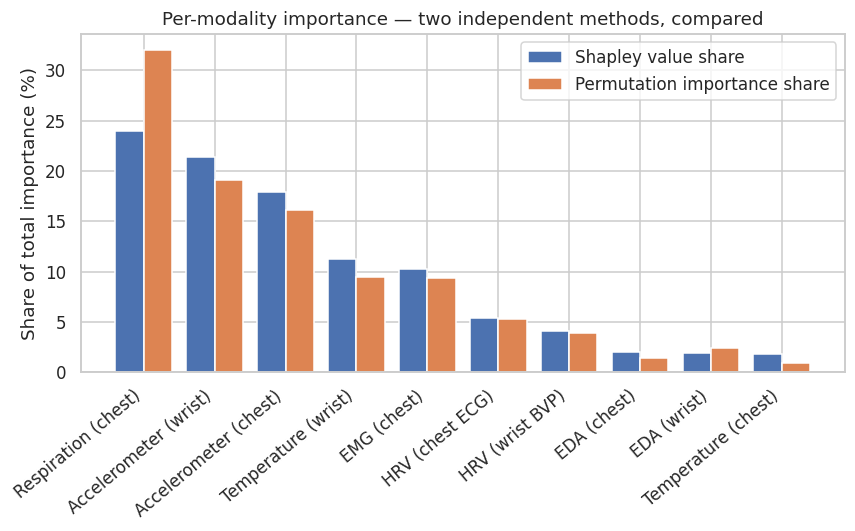

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
order = combined.index
x = np.arange(len(order))
shap_pct = 100 * combined["Shapley value (mean |·|)"] / combined["Shapley value (mean |·|)"].sum()
perm_pct = 100 * combined["Permutation importance (LOSO-avg)"] / combined["Permutation importance (LOSO-avg)"].sum()
ax.bar(x - 0.2, shap_pct, width=0.4, label="Shapley value share", color="#4C72B0")
ax.bar(x + 0.2, perm_pct, width=0.4, label="Permutation importance share", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=40, ha="right")
ax.set_ylabel("Share of total importance (%)")
ax.set_title("Per-modality importance — two independent methods, compared")
ax.legend()
plt.tight_layout()
plt.show()


Both methods agree closely: **respiration and movement (accelerometer) dominate**, followed by wrist temperature and EMG, with EDA and chest temperature contributing the least *marginal* signal in this particular dataset/feature set (though EDA remains a statistically significant univariate discriminator on its own — see `docs/REPORT.md` Section 5.3 for the full discussion of why marginal and univariate importance can diverge).

**Bottom line:** a gradient-boosted model using respiration, movement, temperature, and muscle-tension features, evaluated on subjects it has never seen, distinguishes baseline / stress / amusement with 89.1% accuracy — a solid, physiologically interpretable result, and a validated, reproducible pipeline end to end.